# Classification - Breast Cancer Wisconsin (Diagnostic)

[UCI - Breast Cancer Wisconsin (Diagnostic) Data Set](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic))


**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")


In [2]:
cancer_df = pd.read_csv('cancer_classification.csv')

In [3]:
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Exploratory Data Analysis

In [4]:
cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
cancer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Check whether it is well balanced data or not


In [6]:
cancer_df["benign_0__mal_1"].value_counts()

benign_0__mal_1
1    357
0    212
Name: count, dtype: int64

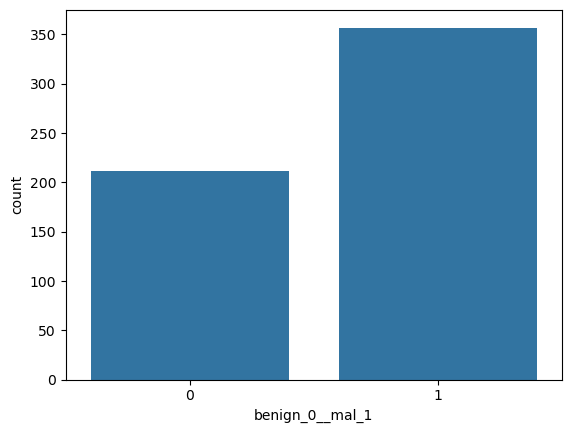

In [7]:
sns.countplot(data=cancer_df ,x= "benign_0__mal_1")
plt.show()

Although cases with 1 is more than 0 cases, the difference is not that extreme. 

## Check correlation

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5208\759135277.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0)` for the same effect.

  sns.barplot(cancer_df.corr() , ci = 0)


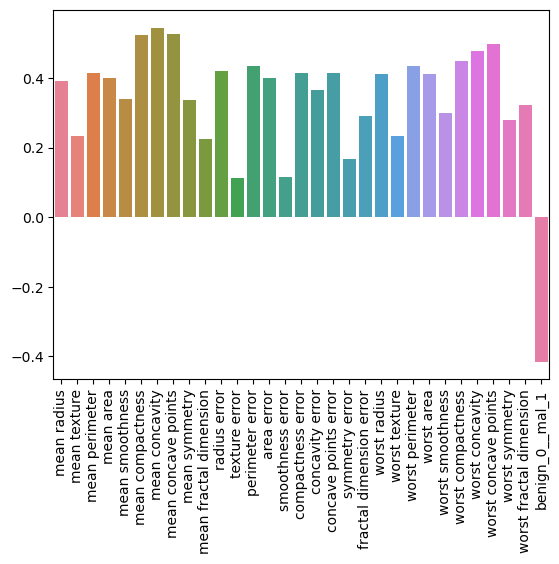

In [8]:
sns.barplot(cancer_df.corr() , ci = 0)
plt.xticks(rotation = 90)
plt.show()

# Train Test Split


In [9]:
x = cancer_df.drop("benign_0__mal_1" , axis=1)
y = cancer_df["benign_0__mal_1"]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=42)

# Scaling Data

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.compile(optimizer='rmsprop',loss='binary_crossentropy')

In [15]:
X_train.shape

(455, 30)

In [16]:
"in input layer model.add(Dense(units = 30 ,input_shape = (30,) //or input_dim = 30//, activation = relu))"
model.add(Dense(units = 60 ,input_shape = (30,), activation = "relu"))
model.add(Dense(units = 30 , activation = "relu"))
model.add(Dense(units = 15 , activation = "relu"))
model.add(Dense(units = 15 , activation = "relu"))
model.add(Dense(units = 1))
model.compile(optimizer="rmsprop" , loss="mse" )
model.summary()

d:\anaconda\anaconda\envs\keras-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 60)             │         1,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411 (17.23 KB)

 Trainable params: 4,411 (17.23 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model


In [17]:
model.fit(x= X_train_scaled , y= y_train , epochs=600, batch_size=64 , verbose=1 , validation_data=(X_test_scaled , y_test))

Epoch 1/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.5214 - val_loss: 0.3739
Epoch 2/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3388 - val_loss: 0.2799
Epoch 3/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2517 - val_loss: 0.2103
Epoch 4/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1940 - val_loss: 0.1780
Epoch 5/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1549 - val_loss: 0.1306
Epoch 6/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1332 - val_loss: 0.1015
Epoch 7/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1095 - val_loss: 0.1100
Epoch 8/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0953 - val_loss: 0.0838
Epoch 9/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0884 - val_loss: 0.0687
Epoch 10/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0741 - val_loss: 0.0926
Epoch 11/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0709 - val_loss: 0.0641
Epoch 12/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0613 - val_lo

## Check history of Training

In [18]:
losses = pd.DataFrame(model.history.history)
losses.head()

,loss,val_loss
0,0.521432,0.373928
1,0.338794,0.279919
2,0.251681,0.210333
3,0.194043,0.177967
4,0.154901,0.130612


<Axes: >

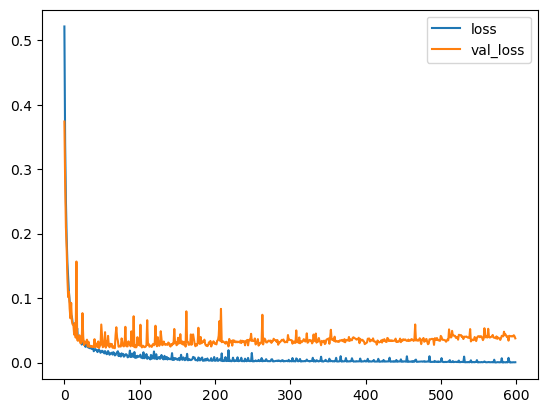

In [19]:
losses.plot()

We can see from the chart that our model is OVERFITTING because `val_loss`suddenly spikes up after a certain epochs.

# Model Building (with Early Stopping)

## Early stopping

Stop training when a monitored quantity has stopped improving.

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
early_stop = EarlyStopping(monitor="val_loss" , mode = "min" , verbose= 1 , patience= 30)

## Model Training with Early Stopping

In [39]:
model2 = Sequential([
    Dense(60, input_shape=(30,), activation='relu'),
    Dense(30, activation='relu'),
    Dense(15, activation='relu'),
    Dense(15, activation='relu'),
    Dense(1)
])
model2.compile(optimizer='rmsprop', loss='mse')

d:\anaconda\anaconda\envs\keras-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model2.fit(x= X_train_scaled , y= y_train , epochs=600, batch_size=64 , verbose=1 , callbacks= [early_stop] , validation_data=(X_test_scaled , y_test))

Epoch 1/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3678 - val_loss: 0.2342
Epoch 2/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2085 - val_loss: 0.1989
Epoch 3/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1545 - val_loss: 0.1272
Epoch 4/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1244 - val_loss: 0.0929
Epoch 5/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0927 - val_loss: 0.1001
Epoch 6/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0962 - val_loss: 0.0674
Epoch 7/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0776 - val_loss: 0.0609
Epoch 8/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0735 - val_loss: 0.0571
Epoch 9/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0673 - val_loss: 0.0778
Epoch 10/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0623 - val_loss: 0.0495
Epoch 11/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0611 - val_loss: 0.0833
Epoch 12/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0639 - val_loss

Now we can see that because of Early Stopping, the model traning got stopped once there is no improvement in training (after 87 epoch).


## Check history of Training (with Early Stopping)

In [41]:
losses2 = pd.DataFrame(model2.history.history)

<Axes: >

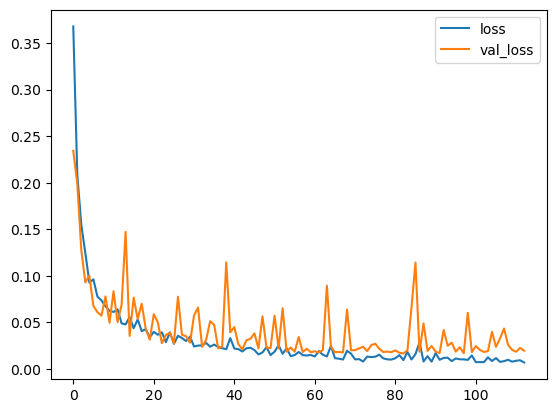

In [42]:
losses2.plot()

# Model Building (with Adding in DropOut Layers)
* Turn off % of neurons randomly
* `rate`: 0 - 1 (percentage of neurons to be turned off randomly while training on each epoch)

In [43]:
from tensorflow.keras.layers import Dropout

## Model Training with Early Stopping

In [44]:
model3 = Sequential([
    Dense(60, input_shape=(30,), activation='relu'),
    Dropout(rate=0.3),
    Dense(30, activation='relu'),
    Dropout(rate=0.3),
    Dense(15, activation='relu'),
    Dense(15, activation='relu'),
    Dense(1)
])

d:\anaconda\anaconda\envs\keras-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model3.compile(optimizer='rmsprop', loss='mse')
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 60)             │         1,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411 (17.23 KB)

 Trainable params: 4,411 (17.23 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model3.fit(x= X_train_scaled , y= y_train , epochs=600, batch_size=64 , verbose=1 , callbacks= [early_stop] , validation_data=(X_test_scaled , y_test))

Epoch 1/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6161 - val_loss: 0.4206
Epoch 2/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4103 - val_loss: 0.3022
Epoch 3/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3247 - val_loss: 0.2564
Epoch 4/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2907 - val_loss: 0.2139
Epoch 5/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2531 - val_loss: 0.1909
Epoch 6/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2063 - val_loss: 0.1524
Epoch 7/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1856 - val_loss: 0.1286
Epoch 8/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1724 - val_loss: 0.1260
Epoch 9/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1795 - val_loss: 0.1002
Epoch 10/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1514 - val_loss: 0.0918
Epoch 11/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1337 - val_loss: 0.0819
Epoch 12/600
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1266 - val_lo

## Check history of losses

In [47]:
losses3 = pd.DataFrame(model3.history.history)

<Axes: >

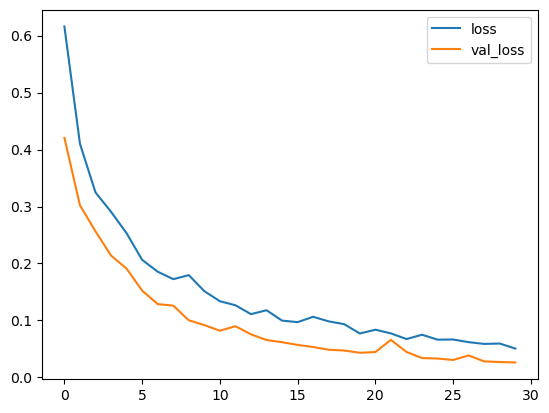

In [48]:
losses3.plot()

We can see that both `loss` and `val_loss` are decreasing almost together and flattening out. This is a great improvment from our original model.


# Model Evaluation

In [49]:
from sklearn.metrics import classification_report, confusion_matrix

In [50]:
raw_predictions = model3.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [51]:
predictions = (raw_predictions > 0.5).astype(int).flatten()

In [52]:
print(classification_report(y_test, predictions, target_names=['Malignant (0)', 'Benign (1)']))

               precision    recall  f1-score   support

Malignant (0)       0.95      0.98      0.97        43
   Benign (1)       0.99      0.97      0.98        71

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



In [53]:
confusion_matrix(y_test, predictions)

array([[42,  1],
       [ 2, 69]])

There are about 3 points which are misclassified.